# Demo Thuật Toán FP-Growth - Khai Phá Luật Kết Hợp

Notebook này minh họa thuật toán FP-Growth cho khai phá itemset phổ biến và sinh luật kết hợp từ dữ liệu giao dịch.

**Nội dung:**
1. Import thư viện cần thiết
2. Nạp và chuẩn bị dữ liệu
3. Chạy thuật toán FP-Growth
4. Phân tích itemset phổ biến
5. Sinh luật kết hợp
6. Trực quan hóa kết quả
7. Xuất thống kê và biểu đồ

## 1. Import Thư Viện Cần Thiết

In [66]:
import sys
import os
import json
import csv
import time
from pathlib import Path
from collections import defaultdict
from typing import List, Set, Dict, Tuple
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm đường dẫn project vào sys.path
project_root = Path().cwd().parent
sys.path.insert(0, str(project_root))

# Import các module từ project
try:
    from src.algorithms.apriori import Apriori
except ImportError:
    Apriori = None

try:
    from src.algorithms.fp_growth import FPGrowth
except ImportError:
    FPGrowth = None

try:
    from src.mining.frequent_itemset import FrequentItemsetManager
    from src.mining.rule_generation import generate_association_rules, filter_rules, sort_rules, get_rules_summary
    from src.evaluation.metrics import MetricsAnalyzer, SupportMetric, ConfidenceMetric, LiftMetric
except ImportError as e:
    print(f"Warning: Could not import all mining modules: {e}")

try:
    from src.evaluation.compare import AlgorithmResult
except ImportError:
    pass

try:
    from src.mining import DatasetLoader
except ImportError:
    DatasetLoader = None

# Cấu hình visualization
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Tạo thư mục outputs
output_dir = project_root / 'outputs' / 'fp_growth'
output_dir.mkdir(parents=True, exist_ok=True)

print(f"✓ Project root: {project_root}")
print(f"✓ Output directory: {output_dir}")
print("✓ Thư viện đã import thành công!")

✓ Project root: /Users/nangvuong/Desktop/association-rule-project
✓ Output directory: /Users/nangvuong/Desktop/association-rule-project/outputs/fp_growth
✓ Thư viện đã import thành công!


In [67]:
# Reload modules để đảm bảo sử dụng code mới nhất
import importlib
import sys

# Reload modules
for module_name in list(sys.modules.keys()):
    if 'src' in module_name:
        del sys.modules[module_name]

# Import lại
from src.algorithms.fp_growth import FPGrowth

print("✓ Modules reloaded successfully!")

✓ Modules reloaded successfully!


## 2. Nạp và Chuẩn Bị Dữ Liệu

In [68]:
# Nạp dữ liệu từ thư mục processed
from src.mining import DatasetLoader

data_dir = project_root / 'data' / 'processed'

try:
    loader = DatasetLoader(data_dir)
    transactions = loader.load_transactions()
    total_transactions = len(transactions)
    
    print(f"\n{'='*70}")
    print("THỐNG KÊ DỮ LIỆU")
    print(f"{'='*70}")
    print(f"Tổng số giao dịch: {total_transactions}")
    
    # Tính toán các thống kê về giao dịch
    transaction_sizes = [len(t) for t in transactions]
    unique_items = set()
    for t in transactions:
        unique_items.update(t)
    
    print(f"Tổng số item duy nhất: {len(unique_items)}")
    print(f"Kích thước giao dịch - Min: {min(transaction_sizes)}, Max: {max(transaction_sizes)}, Avg: {np.mean(transaction_sizes):.2f}")
    
except Exception as e:
    print(f"Error loading data: {e}")
    transactions = []
    total_transactions = 0


THỐNG KÊ DỮ LIỆU
Tổng số giao dịch: 14070
Tổng số item duy nhất: 177
Kích thước giao dịch - Min: 2, Max: 58, Avg: 7.67


## 3. Chạy Thuật Toán FP-Growth

In [69]:
from dotenv import load_dotenv

# Nạp các tham số từ .env
env_file = project_root / '.env'
load_dotenv(env_file)

# Đọc các tham số từ biến môi trường
min_support = int(os.getenv('MINING_MIN_SUPPORT', 100))
min_confidence = float(os.getenv('MINING_MIN_CONFIDENCE', 0.5))

print(f"\n{'='*70}")
print("CHẠY FP-GROWTH")
print(f"{'='*70}")
print(f"📋 Tham số được nạp từ .env file: {env_file}")
print(f"Tham số: min_support={min_support}, min_confidence={min_confidence}\n")

# Chạy FP-Growth (chỉ cần min_support, min_confidence dùng cho rule generation)
if FPGrowth is not None:
    fpgrowth = FPGrowth(min_support=min_support)
    fpgrowth_result = fpgrowth.fit(transactions)
    
    # Lưu kết quả
    frequent_itemsets = fpgrowth_result['frequent_itemsets']
    support_counts = fpgrowth_result['support_counts']
    total_itemsets = fpgrowth_result['total_itemsets']
    execution_time = fpgrowth_result['execution_time']
    
    print(f"\n✓ Execution time: {execution_time:.4f} seconds")
    print(f"✓ Total itemsets: {total_itemsets}")
else:
    print("❌ FP-Growth not available. Please check src/algorithms/fp_growth.py")
    frequent_itemsets = {}
    support_counts = {}
    total_itemsets = 0
    execution_time = 0


CHẠY FP-GROWTH
📋 Tham số được nạp từ .env file: /Users/nangvuong/Desktop/association-rule-project/.env
Tham số: min_support=100, min_confidence=0.5

THUAT TOAN FP-GROWTH - KHAI PHA MAU TAN SUAT
So giao dich: 14070
Support toi thieu: 100

Xay dung FP-Tree...
FP-Tree duoc xay dung voi 177 hang pho bien

  Tien trinh: Tim thay 1000 itemsets

Tong itemset pho bien: 1167
Thoi gian thuc thi: 1.82 giay

✓ Execution time: 1.8219 seconds
✓ Total itemsets: 1167


## 4. Phân Tích Itemset Phổ Biến

In [70]:
# Phân tích itemsets
itemset_stats = []

print(f"\n{'='*70}")
print("PHÂN TÍCH ITEMSETS")
print(f"{'='*70}")
for size in sorted(frequent_itemsets.keys()):
    count = len(frequent_itemsets[size])
    itemset_stats.append({'Size': size, 'Count': count})
    print(f"Kích thước {size}: {count} itemsets")

# Tính toán phân bố support
support_values = list(support_counts.values())
support_stats = {
    'Min': min(support_values) if support_values else 0,
    'Max': max(support_values) if support_values else 0,
    'Mean': np.mean(support_values) if support_values else 0,
    'Median': np.median(support_values) if support_values else 0,
    'Std': np.std(support_values) if support_values else 0
}

print(f"\n{'='*70}")
print("PHÂN BỐ SUPPORT")
print(f"{'='*70}")
for key, value in support_stats.items():
    print(f"{key:10s}: {value:.2f}")

# Hiển thị top 10 itemsets theo support
print(f"\n{'='*70}")
print("TOP 10 ITEMSETS THEO SUPPORT")
print(f"{'='*70}")
top_itemsets = sorted(support_counts.items(), key=lambda x: x[1], reverse=True)[:10]
for i, (itemset, support) in enumerate(top_itemsets, 1):
    pct = (support / total_transactions) * 100 if total_transactions > 0 else 0
    print(f"{i:2d}. {str(itemset):30s} - Support: {support:4d} ({pct:.2f}%)")


PHÂN TÍCH ITEMSETS
Kích thước 1: 177 itemsets
Kích thước 2: 760 itemsets
Kích thước 3: 198 itemsets
Kích thước 4: 31 itemsets
Kích thước 5: 1 itemsets

PHÂN BỐ SUPPORT
Min       : 100.00
Max       : 2904.00
Mean      : 227.16
Median    : 144.00
Std       : 204.55

TOP 10 ITEMSETS THEO SUPPORT
 1. ('WHITE HANGING HEART T-LIGHT HOLDER',) - Support: 2904 (20.64%)
 2. ('REGENCY CAKESTAND 3 TIER',)  - Support: 1580 (11.23%)
 3. ('STRAWBERRY CERAMIC TRINKET BOX',) - Support: 1296 (9.21%)
 4. ('ASSORTED COLOUR BIRD ORNAMENT',) - Support: 1284 (9.13%)
 5. ('HOME BUILDING BLOCK WORD',)  - Support: 1155 (8.21%)
 6. ('PACK OF 72 RETRO SPOT CAKE CASES',) - Support: 1155 (8.21%)
 7. ('60 TEATIME FAIRY CAKE CASES',) - Support: 1133 (8.05%)
 8. ('LUNCH BAG RED SPOTTY',)      - Support: 1056 (7.51%)
 9. ('JUMBO BAG RED RETROSPOT',)   - Support: 1042 (7.41%)
10. ('REX CASH+CARRY JUMBO SHOPPER',) - Support:  999 (7.10%)


## 5. Sinh Luật Kết Hợp

In [71]:
# Sinh luật kết hợp
from itertools import combinations

def generate_rules_from_itemsets(frequent_itemsets, support_counts, min_confidence, total_transactions):
    """Sinh luật kết hợp từ itemsets phổ biến"""
    rules = []
    
    # Chỉ xét các itemsets có kích thước >= 2
    for size in sorted(frequent_itemsets.keys()):
        if size < 2:
            continue
            
        for itemset in frequent_itemsets[size]:
            itemset_tuple = tuple(sorted(itemset))
            itemset_support = support_counts.get(itemset_tuple, 0)
            
            # Sinh tất cả các quy tắc từ itemset này
            for i in range(1, size):
                for antecedent in combinations(itemset, i):
                    antecedent = tuple(sorted(antecedent))
                    consequent = tuple(sorted(set(itemset_tuple) - set(antecedent)))
                    
                    antecedent_support = support_counts.get(antecedent, 0)
                    consequent_support = support_counts.get(consequent, 0)
                    
                    # Cả antecedent và consequent phải có trong itemsets phổ biến
                    if antecedent_support == 0 or consequent_support == 0:
                        continue
                    
                    confidence = itemset_support / antecedent_support
                    
                    if confidence >= min_confidence:
                        # Lift = support(A∪B) / (support(A) * support(B))
                        lift = itemset_support / (antecedent_support * consequent_support)
                        
                        rules.append({
                            'antecedent': antecedent,
                            'consequent': consequent,
                            'support': itemset_support,
                            'confidence': confidence,
                            'lift': lift
                        })
    
    return rules

# Sinh luật
rules_dict = generate_rules_from_itemsets(frequent_itemsets, support_counts, min_confidence, total_transactions)

print(f"\n{'='*70}")
print("SINH LUẬT KẾT HỢP")
print(f"{'='*70}")
print(f"Tổng luật sinh được: {len(rules_dict)}")

# Tính toán thống kê về luật
if rules_dict:
    confidences = [r['confidence'] for r in rules_dict]
    lifts = [r['lift'] for r in rules_dict]
    
    print(f"\nThống kê Confidence:")
    print(f"  Min: {min(confidences):.4f}")
    print(f"  Max: {max(confidences):.4f}")
    print(f"  Mean: {np.mean(confidences):.4f}")
    
    print(f"\nThống kê Lift:")
    print(f"  Min: {min(lifts):.4f}")
    print(f"  Max: {max(lifts):.4f}")
    print(f"  Mean: {np.mean(lifts):.4f}")
    
    # Hiển thị top 10 luật theo confidence
    print(f"\n{'='*70}")
    print("TOP 10 LUẬT THEO CONFIDENCE")
    print(f"{'='*70}")
    
    top_rules = sorted(rules_dict, key=lambda x: x['confidence'], reverse=True)[:10]
    for i, rule in enumerate(top_rules, 1):
        antecedent = ', '.join(rule['antecedent'])
        consequent = ', '.join(rule['consequent'])
        print(f"{i:2d}. {{{antecedent}}} => {{{consequent}}}")
        print(f"    Support: {rule['support']}, Confidence: {rule['confidence']:.4f}, Lift: {rule['lift']:.4f}\n")


SINH LUẬT KẾT HỢP
Tổng luật sinh được: 457

Thống kê Confidence:
  Min: 0.5000
  Max: 0.9344
  Mean: 0.6159

Thống kê Lift:
  Min: 0.0002
  Max: 0.0027
  Mean: 0.0008

TOP 10 LUẬT THEO CONFIDENCE
 1. {WHITE HANGING HEART T-LIGHT HOLDER, WOOD 2 DRAWER CABINET WHITE FINISH, WOOD S/3 CABINET ANT WHITE FINISH, WOODEN PICTURE FRAME WHITE FINISH} => {WOODEN FRAME ANTIQUE WHITE}
    Support: 114, Confidence: 0.9344, Lift: 0.0009

 2. {WOOD 2 DRAWER CABINET WHITE FINISH, WOOD S/3 CABINET ANT WHITE FINISH, WOODEN PICTURE FRAME WHITE FINISH} => {WOODEN FRAME ANTIQUE WHITE}
    Support: 191, Confidence: 0.9183, Lift: 0.0009

 3. {WHITE HANGING HEART T-LIGHT HOLDER, WOOD S/3 CABINET ANT WHITE FINISH, WOODEN FRAME ANTIQUE WHITE, WOODEN PICTURE FRAME WHITE FINISH} => {WOOD 2 DRAWER CABINET WHITE FINISH}
    Support: 114, Confidence: 0.9120, Lift: 0.0016

 4. {CERAMIC STRAWBERRY CAKE MONEY BANK, SWEETHEART CERAMIC TRINKET BOX} => {STRAWBERRY CERAMIC TRINKET BOX}
    Support: 127, Confidence: 0.8819,

## 6. Trực Quan Hóa Kết Quả

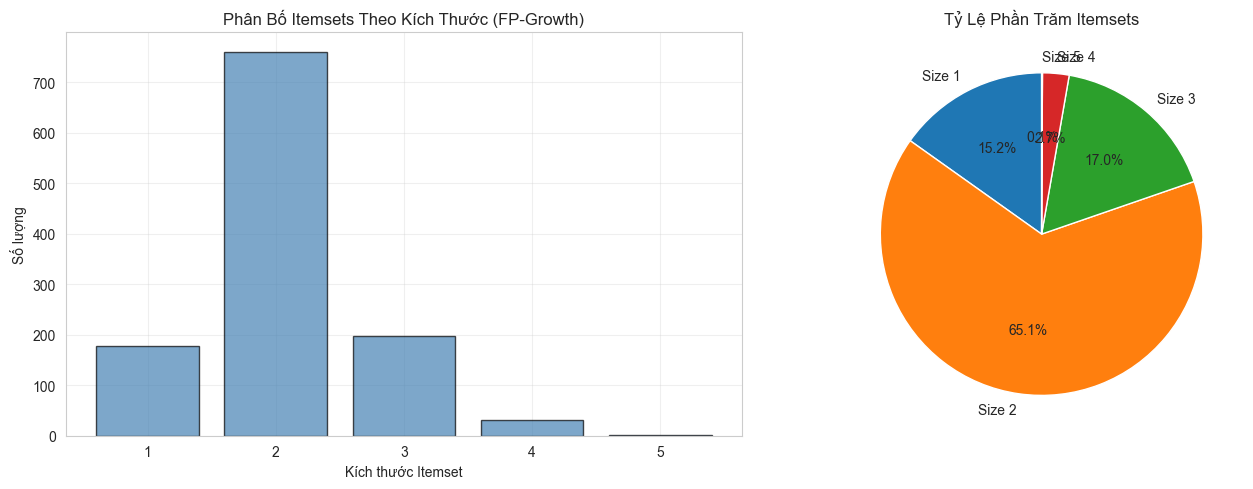

✓ Saved: itemset_distribution.png


In [72]:
### 6.1 Phân Bố Itemsets Theo Kích Thước

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - số lượng itemsets
sizes = sorted(frequent_itemsets.keys())
counts = [len(frequent_itemsets[s]) for s in sizes]

axes[0].bar(sizes, counts, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Kích thước Itemset')
axes[0].set_ylabel('Số lượng')
axes[0].set_title('Phân Bố Itemsets Theo Kích Thước (FP-Growth)')
axes[0].grid(True, alpha=0.3)

# Pie chart - phần trăm
axes[1].pie(counts, labels=[f'Size {s}' for s in sizes], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Tỷ Lệ Phần Trăm Itemsets')

plt.tight_layout()
plt.savefig(output_dir / 'itemset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: itemset_distribution.png")

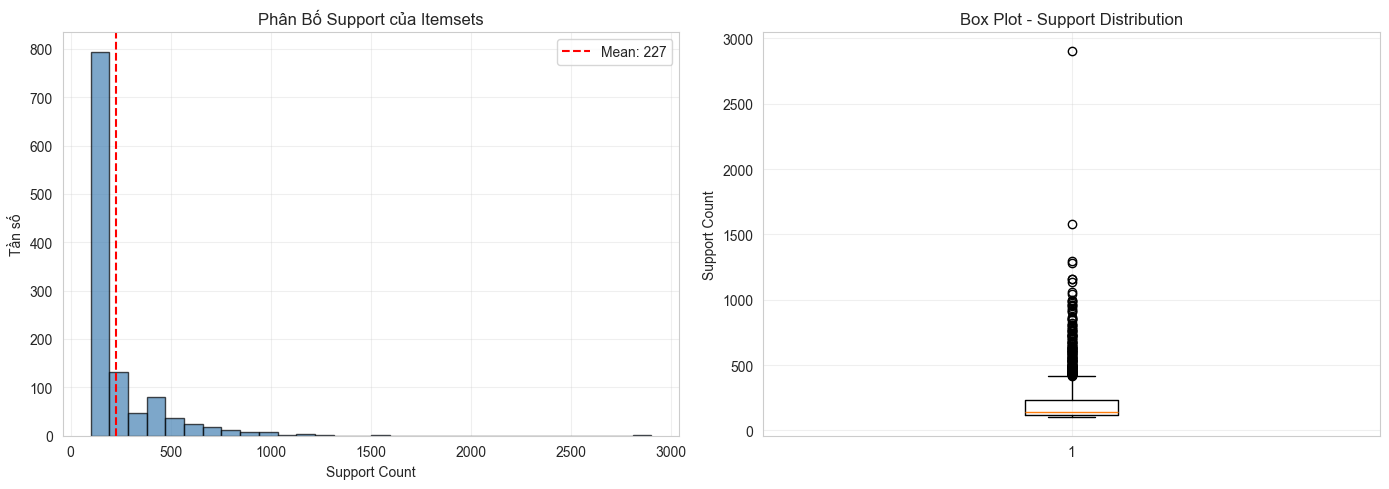

✓ Saved: support_distribution.png


In [73]:
### 6.2 Phân Bố Support

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram - support distribution
axes[0].hist(support_values, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Support Count')
axes[0].set_ylabel('Tần số')
axes[0].set_title('Phân Bố Support của Itemsets')
axes[0].axvline(np.mean(support_values), color='red', linestyle='--', label=f'Mean: {np.mean(support_values):.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(support_values, vert=True)
axes[1].set_ylabel('Support Count')
axes[1].set_title('Box Plot - Support Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / 'support_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: support_distribution.png")

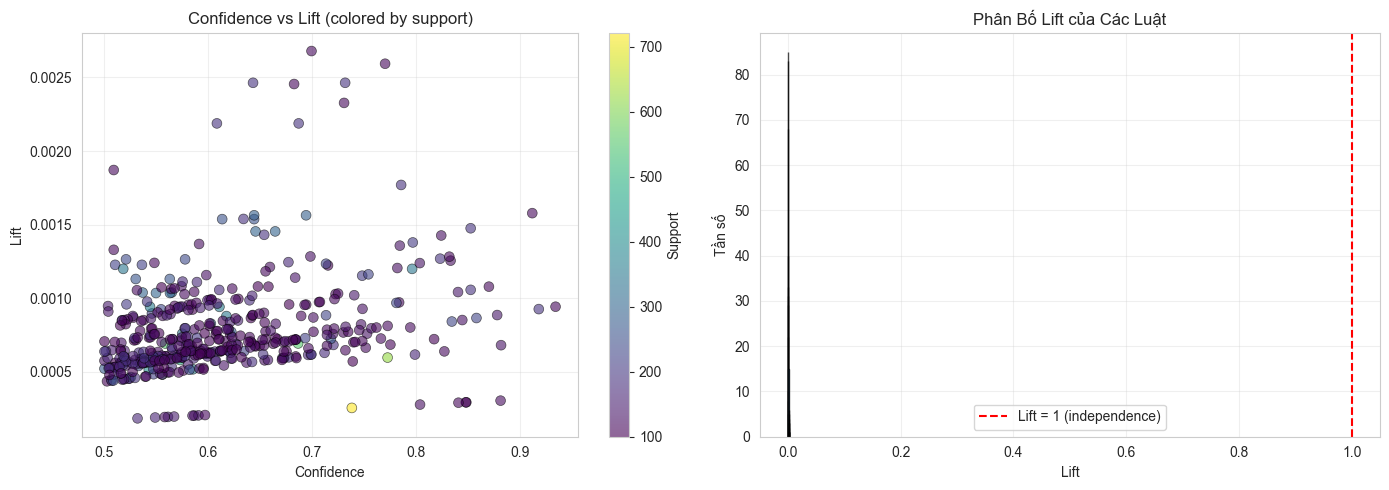

✓ Saved: rules_metrics.png


In [74]:
### 6.3 Scatter Plot - Confidence vs Lift

if rules_dict:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    confidences = [r['confidence'] for r in rules_dict]
    lifts = [r['lift'] for r in rules_dict]
    supports = [r['support'] for r in rules_dict]
    
    # Scatter plot - Confidence vs Lift (colored by support)
    scatter = axes[0].scatter(confidences, lifts, c=supports, cmap='viridis', 
                             alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[0].set_xlabel('Confidence')
    axes[0].set_ylabel('Lift')
    axes[0].set_title('Confidence vs Lift (colored by support)')
    axes[0].grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=axes[0])
    cbar.set_label('Support')
    
    # Histogram - Lift distribution
    axes[1].hist(lifts, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[1].set_xlabel('Lift')
    axes[1].set_ylabel('Tần số')
    axes[1].set_title('Phân Bố Lift của Các Luật')
    axes[1].axvline(1.0, color='red', linestyle='--', label='Lift = 1 (independence)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'rules_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: rules_metrics.png")

## 7. Xuất Thống Kê và Biểu Đồ

In [75]:
### 7.1 Xuất Itemsets

print(f"\n{'='*70}")
print("XUẤT KỀT QUẢ")
print(f"{'='*70}")

# Tạo dataframe từ support counts
itemset_records = []
for itemset_tuple, support in support_counts.items():
    support_pct = (support / total_transactions * 100) if total_transactions > 0 else 0
    itemset_records.append({
        'Itemset': str(itemset_tuple),
        'Size': len(itemset_tuple),
        'Support_Count': support,
        'Support_Percentage': support_pct,
        'Support_Decimal': support / total_transactions if total_transactions > 0 else 0
    })

itemset_df = pd.DataFrame(itemset_records)

# Xuất CSV
itemset_file = output_dir / 'frequent_itemsets.csv'
itemset_df_export = itemset_df[['Itemset', 'Size', 'Support_Count', 'Support_Percentage', 'Support_Decimal']]
itemset_df_export.to_csv(itemset_file, index=False)
print(f"✓ Exported: frequent_itemsets.csv ({len(itemset_df)} rows)")


XUẤT KỀT QUẢ
✓ Exported: frequent_itemsets.csv (1167 rows)


In [76]:
### 7.2 Xuất Luật Kết Hợp

# Tạo dataframe từ rules
rule_records = []
for rule in rules_dict:
    rule_records.append({
        'Antecedent': str(rule['antecedent']),
        'Consequent': str(rule['consequent']),
        'Support': rule['support'],
        'Support_Percentage': (rule['support'] / total_transactions * 100) if total_transactions > 0 else 0,
        'Confidence': rule['confidence'],
        'Lift': rule['lift']
    })

rule_df = pd.DataFrame(rule_records)

# Xuất CSV
rule_file = output_dir / 'association_rules.csv'
rule_df_export = rule_df[['Antecedent', 'Consequent', 'Support', 'Support_Percentage', 'Confidence', 'Lift']]
rule_df_export.to_csv(rule_file, index=False)
print(f"✓ Exported: association_rules.csv ({len(rule_df)} rows)")

✓ Exported: association_rules.csv (457 rows)


In [77]:
### 7.3 Xuất Thống Kê

# Tính toán thống kê
stats_data = {
    'Algorithm': 'FP-Growth + Apriori Rule Generator',
    'Parameters': {
        'min_support': min_support,
        'min_confidence': min_confidence
    },
    'Data': {
        'total_transactions': total_transactions,
        'unique_items': len(unique_items),
        'avg_transaction_size': float(np.mean(transaction_sizes)) if transaction_sizes else 0,
        'min_transaction_size': int(min(transaction_sizes)) if transaction_sizes else 0,
        'max_transaction_size': int(max(transaction_sizes)) if transaction_sizes else 0
    },
    'Itemsets': {
        'total_itemsets': total_itemsets,
        'itemset_stats': itemset_stats,
        'support': {
            'min': float(support_stats['Min']),
            'max': float(support_stats['Max']),
            'mean': float(support_stats['Mean']),
            'median': float(support_stats['Median']),
            'std': float(support_stats['Std'])
        }
    },
    'Rules': {
        'total_rules': len(rules_dict),
        'confidence': {
            'min': float(min(confidences)) if confidences else 0,
            'max': float(max(confidences)) if confidences else 0,
            'mean': float(np.mean(confidences)) if confidences else 0
        },
        'lift': {
            'min': float(min(lifts)) if lifts else 0,
            'max': float(max(lifts)) if lifts else 0,
            'mean': float(np.mean(lifts)) if lifts else 0
        }
    },
    'Performance': {
        'execution_time_seconds': execution_time
    }
}

# Xuất JSON
stats_file = output_dir / 'statistics.json'
with open(stats_file, 'w') as f:
    json.dump(stats_data, f, indent=2)
print(f"✓ Exported: statistics.json")

# Xuất CSV format cho spreadsheet
stats_csv_data = []
stats_csv_data.append(['Metric', 'Value'])
stats_csv_data.append(['Algorithm', stats_data['Algorithm']])
stats_csv_data.append(['min_support', min_support])
stats_csv_data.append(['min_confidence', min_confidence])
stats_csv_data.append(['Total Transactions', total_transactions])
stats_csv_data.append(['Unique Items', len(unique_items)])
stats_csv_data.append(['Total Itemsets', total_itemsets])
stats_csv_data.append(['Total Rules', len(rules_dict)])
stats_csv_data.append(['Execution Time (seconds)', f"{execution_time:.4f}"])

stats_csv_file = output_dir / 'statistics.csv'
with open(stats_csv_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerows(stats_csv_data)
print(f"✓ Exported: statistics.csv")

✓ Exported: statistics.json
✓ Exported: statistics.csv


In [78]:
### 7.4 Tóm Tắt Xuất Kết Quả

output_files = [
    itemset_file,
    rule_file,
    stats_file,
    stats_csv_file,
    output_dir / 'itemset_distribution.png',
    output_dir / 'support_distribution.png',
    output_dir / 'rules_metrics.png'
]

print(f"\n{'='*70}")
print("TÓM TẮT XUẤT KỀT QUẢ")
print(f"{'='*70}")
for file in output_files:
    if file.exists():
        size = file.stat().st_size / 1024  # KB
        print(f"✓ {file.name:30s} ({size:.1f} KB)")
    else:
        print(f"✗ {file.name:30s} (not found)")

print(f"\n✓ Output directory: {output_dir}")


TÓM TẮT XUẤT KỀT QUẢ
✓ frequent_itemsets.csv          (127.9 KB)
✓ association_rules.csv          (75.1 KB)
✓ statistics.json                (1.2 KB)
✓ statistics.csv                 (0.2 KB)
✓ itemset_distribution.png       (157.0 KB)
✓ support_distribution.png       (141.5 KB)
✓ rules_metrics.png              (511.0 KB)

✓ Output directory: /Users/nangvuong/Desktop/association-rule-project/outputs/fp_growth
